
# Integración del Motor de Recomendación de Nutrición — ASCEND

(OpenAI para visión/traducción,
Spoonacular para recetas/nutrición) e
## Antes de correr este notebook

1. Coloca un archivo `.env` en **esta misma carpeta** con:
   ```
   OPENAI_API_KEY=sk-...
   SPOONACULAR_API_KEY=...
   ```
2. Coloca una foto de un refri/despensa en esta misma carpeta con el
   nombre `foto_refri.jpg` (puedes cambiar el nombre en la celda
   correspondiente si prefieres otro).
3. Ten presente la cuota gratuita de Spoonacular: **50 puntos/día**.
   Cada corrida completa de este notebook gasta cuota real

Todo el código de las funciones es una copia fiel de
`utils_nutricion.py` — no una versión simplificada.


In [ ]:

import base64
import json
from pathlib import Path

import requests
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from openai import OpenAI
from IPython.display import Image as IPImage, display

import os

CARPETA_NOTEBOOK = Path.cwd()
load_dotenv(CARPETA_NOTEBOOK / ".env", override=True)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
SPOONACULAR_API_KEY = os.getenv("SPOONACULAR_API_KEY")
SPOONACULAR_BASE_URL = "https://api.spoonacular.com"
MODELO_VISION = "gpt-5.4-mini"

VERDE_PRIMARIO = "#006a20"
VERDE_MEDIO = "#20a04e"
CASI_NEGRO = "#141d16"

def _verificar(nombre, valor):
    estado = "detectada ✅" if valor else "FALTANTE ❌ — revisa tu .env"
    print(f"{nombre}: {estado}")

_verificar("OPENAI_API_KEY", OPENAI_API_KEY)
_verificar("SPOONACULAR_API_KEY", SPOONACULAR_API_KEY)

import warnings
warnings.filterwarnings("ignore")


OPENAI_API_KEY: detectada ✅
SPOONACULAR_API_KEY: detectada ✅



## Funciones


In [3]:
class ErrorNutricion(Exception):
    """Error controlado (cuota agotada, red caída, respuesta rara del LLM)
    para poder atraparlo específicamente en vez de un Exception genérico
    — en la app real, esto le permite a la página mostrar un mensaje
    amigable en vez de tronar con un traceback."""
    pass


def identificar_ingredientes_de_foto(imagen_bytes: bytes) -> list[str]:
    """
    Manda una foto de refrigerador/despensa a un modelo de visión y regresa
    una lista simple de ingredientes EN INGLÉS (requisito de Spoonacular,
    que solo reconoce nombres de ingredientes en ese idioma).

    Se le pide al modelo el inglés desde este primer paso (en vez de
    pedirlo en español y traducir después) para ahorrarse una llamada
    extra — todo lo que sigue en el pipeline ya trabaja en inglés.

    Parameters
    ----------
    imagen_bytes : bytes
        Contenido crudo de la foto (ej. lo que regresa `foto.getvalue()`
        de un `st.file_uploader`).

    Returns
    -------
    list[str]
        Ingredientes genéricos detectados, en minúsculas y sin espacios
        sobrantes (ej. ["egg", "milk", "tomato"]). Lista vacía si el
        modelo no identificó nada.
    """
    client = OpenAI(api_key=OPENAI_API_KEY)
    imagen_b64 = base64.b64encode(imagen_bytes).decode("utf-8")

    prompt = (
        "Look at this photo of a fridge or pantry. List every distinct food "
        "ingredient you can actually identify. Respond with ONLY a JSON array "
        "of simple, generic ingredient names in English (e.g. [\"egg\", \"milk\", "
        "\"tomato\", \"chicken breast\"]) — no brand names, no extra text, no "
        "markdown fences, just the JSON array. If you cannot identify any food "
        "ingredients, respond with []."
    )
    respuesta = client.chat.completions.create(
        model=MODELO_VISION,
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                # Se manda como data URL en base64 — no se sube el archivo
                # a ningún storage intermedio, va directo en el request
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{imagen_b64}"}},
            ],
        }],
        max_completion_tokens=500,
    )
    texto = respuesta.choices[0].message.content.strip()
    # El modelo a veces envuelve el JSON en ```json ... ``` aunque se le
    # pida que no lo haga — se limpia por seguridad antes de parsear
    texto_limpio = texto.replace("```json", "").replace("```", "").strip()
    ingredientes = json.loads(texto_limpio)
    return [str(i).strip().lower() for i in ingredientes if str(i).strip()]


def traducir_ingredientes_a_ingles(ingredientes: list[str]) -> list[str]:
    """
    Traduce/normaliza una lista de ingredientes (en el idioma que sea) a
    nombres genéricos en inglés que Spoonacular pueda reconocer.

    Existe porque si el usuario ESCRIBE los ingredientes a mano en vez de
    subir una foto (ej. "arroz, jitomate"), nunca pasaban por ningún paso
    de traducción — Spoonacular (inglés únicamente) regresaba 0
    resultados siempre, sin importar qué tan común fuera el ingrediente
    real. Esta función cierra ese hueco.

    Parameters
    ----------
    ingredientes : list[str]
        Ingredientes en español, inglés, o una mezcla de ambos.

    Returns
    -------
    list[str]
        Los mismos ingredientes, mismo orden y misma longitud, ya en
        inglés y en minúsculas. Lista vacía si la entrada estaba vacía.
    """
    if not ingredientes:
        return []
    client = OpenAI(api_key=OPENAI_API_KEY)
    prompt = (
        "Translate/normalize this list of food ingredients (they may be in "
        "Spanish, English, or mixed) into simple, generic ingredient names "
        "in English that a recipe database would recognize (e.g. 'arroz' -> "
        "'rice', 'jitomate' -> 'tomato', 'pechuga de pollo' -> 'chicken "
        f"breast'). Ingredients: {ingredientes}. Respond with ONLY a JSON "
        "array of strings, same order, same length, no extra text, no "
        "markdown fences."
    )
    respuesta = client.chat.completions.create(
        model=MODELO_VISION, messages=[{"role": "user", "content": prompt}], max_completion_tokens=300,
    )
    texto_limpio = respuesta.choices[0].message.content.strip().replace("```json", "").replace("```", "").strip()
    traducidos = json.loads(texto_limpio)
    return [str(i).strip().lower() for i in traducidos]


def traducir_ingredientes_a_espanol(ingredientes: list[str]) -> list[str]:
    """
    Dirección inversa a `traducir_ingredientes_a_ingles` — Spoonacular
    regresa `usedIngredients`/`missedIngredients` en inglés; esta función
    los traduce SOLO para mostrarlos en pantalla al usuario (la búsqueda
    en Spoonacular sigue haciéndose siempre en inglés, esto no afecta
    ninguna llamada a la API).

    Parameters
    ----------
    ingredientes : list[str]
        Nombres de ingredientes en inglés, tal como los regresa Spoonacular.

    Returns
    -------
    list[str]
        Los mismos ingredientes en español natural (LATAM), mismo orden
        y longitud. Lista vacía si la entrada estaba vacía.
    """
    if not ingredientes:
        return []
    client = OpenAI(api_key=OPENAI_API_KEY)
    prompt = (
        f"Translate this list of food ingredient names to natural Spanish "
        f"(Latin American, simple everyday words): {ingredientes}. Respond "
        "with ONLY a JSON array of strings, same order, same length, no "
        "extra text, no markdown fences."
    )
    respuesta = client.chat.completions.create(
        model=MODELO_VISION, messages=[{"role": "user", "content": prompt}], max_completion_tokens=300,
    )
    texto_limpio = respuesta.choices[0].message.content.strip().replace("```json", "").replace("```", "").strip()
    return json.loads(texto_limpio)


def _extraer_nutrientes(info_receta: dict) -> dict:
    """
    Convierte la lista variable de nutrientes de Spoonacular
    (`nutrition.nutrients`, una lista de dicts, no campos fijos) en un
    dict plano con solo los 4 nutrientes que la app muestra.

    Parameters
    ----------
    info_receta : dict
        Respuesta de Spoonacular para una receta, con la llave
        "nutrition.nutrients" presente (requiere haber pedido la receta
        con `addRecipeNutrition=true` o `includeNutrition=true`).

    Returns
    -------
    dict
        {"calorias", "proteina_g", "grasa_g", "carbohidratos_g"} — con
        valor None en cualquiera que Spoonacular no haya incluido para
        esa receta en particular.
    """
    nutrientes_buscados = {"Calories": "calorias", "Protein": "proteina_g", "Fat": "grasa_g", "Carbohydrates": "carbohidratos_g"}
    resultado = {v: None for v in nutrientes_buscados.values()}
    for nutriente in info_receta.get("nutrition", {}).get("nutrients", []):
        if nutriente.get("name") in nutrientes_buscados:
            resultado[nutrientes_buscados[nutriente["name"]]] = round(nutriente.get("amount", 0), 1)
    return resultado


def buscar_opciones_comida(ingredientes: list[str], n_opciones: int = 3) -> list[dict]:
    """
    Busca recetas que aprovechen los ingredientes dados y regresa
    `n_opciones` con su información nutricional ya calculada.

    Usa 2 llamadas a Spoonacular en total (`findByIngredients` +
    `informationBulk`, esta última en una sola petición para todos los
    candidatos) para cuidar la cuota del plan gratis (50 puntos/día).
    `ranking=2` le pide a Spoonacular que minimice ingredientes
    faltantes, así el primer resultado siempre es el más cercano a lo
    que el usuario ya tiene disponible.

    Parameters
    ----------
    ingredientes : list[str]
        Ingredientes disponibles, YA en inglés (ver
        `traducir_ingredientes_a_ingles`).
    n_opciones : int, default 3
        Cuántas opciones finales regresar.

    Returns
    -------
    list[dict]
        Cada dict trae id, titulo, imagen_url, ingredientes usados/
        faltantes, los 4 nutrientes, tiempo de preparación y porciones.
        Lista vacía si no hay ingredientes o Spoonacular no encontró nada.

    Raises
    ------
    ErrorNutricion
        Si se acabó la cuota (402) o Spoonacular regresa cualquier otro error.
    """
    if not ingredientes:
        return []
    # Pedimos más candidatos de los que mostramos, para tener de dónde
    # elegir los `n_opciones` más cercanos sin gastar cuota de más
    n_candidatos_a_pedir = max(n_opciones, 10)
    resp_busqueda = requests.get(
        f"{SPOONACULAR_BASE_URL}/recipes/findByIngredients",
        params={"ingredients": ",".join(ingredientes), "number": n_candidatos_a_pedir,
                "ranking": 2, "ignorePantry": "true", "apiKey": SPOONACULAR_API_KEY},
        timeout=15,
    )
    if resp_busqueda.status_code == 402:
        raise ErrorNutricion("Se acabó la cuota gratuita de Spoonacular por hoy (50 puntos/día).")
    resp_busqueda.raise_for_status()
    candidatos = resp_busqueda.json()[:n_opciones]
    if not candidatos:
        return []

    # Segunda llamada: trae la nutrición de TODOS los candidatos elegidos
    # en una sola petición (más barato en cuota que pedir uno por uno)
    ids = ",".join(str(c["id"]) for c in candidatos)
    resp_info = requests.get(
        f"{SPOONACULAR_BASE_URL}/recipes/informationBulk",
        params={"ids": ids, "includeNutrition": "true", "apiKey": SPOONACULAR_API_KEY},
        timeout=15,
    )
    resp_info.raise_for_status()
    info_por_id = {r["id"]: r for r in resp_info.json()}

    opciones = []
    for candidato in candidatos:
        info = info_por_id.get(candidato["id"])
        if not info:
            continue  # por si informationBulk no regresó ese id en particular
        nutrientes = _extraer_nutrientes(info)
        opciones.append({
            "id": candidato["id"], "titulo": candidato["title"], "imagen_url": candidato.get("image"),
            "ingredientes_usados": [i["name"] for i in candidato.get("usedIngredients", [])],
            "ingredientes_faltantes": [i["name"] for i in candidato.get("missedIngredients", [])],
            **nutrientes,
            "listo_en_minutos": info.get("readyInMinutes"), "porciones": info.get("servings"),
        })
    return opciones


def calcular_objetivo_nutricional(perfil: dict) -> dict:
    """
    A partir del perfil físico del usuario (peso, estatura, edad, sexo) y
    su objetivo declarado, calcula: calorías objetivo, proteína, grasa y
    carbohidratos en gramos para el día.

    Usa Mifflin-St Jeor para el metabolismo basal (BMR) — elegida sobre
    Harris-Benedict por su menor error de validación en sobrepeso/
    obesidad (ver comparación en el notebook de EDA). Es una ESTIMACIÓN
    general, no un plan clínico. No llama a ninguna API — es 100% local.

    Parameters
    ----------
    perfil : dict
        Debe traer "weight_kg", "height_cm", "age", "gender_code" ("M" u
        otro valor), y opcionalmente "objetivo" (si falta, cae a
        "Salud general").

    Returns
    -------
    dict
        {"calorias", "proteina_g", "grasa_g", "carbohidratos_g"} — la
        meta diaria completa.
    """
    peso, altura, edad, sexo = perfil["weight_kg"], perfil["height_cm"], perfil["age"], perfil["gender_code"]
    objetivo = perfil.get("objetivo") or "Salud general"
    AJUSTE = {"Bajar de peso": -500, "Ganar músculo": 300, "Ganar fuerza": 200, "Mejorar resistencia/cardio": 0, "Salud general": 0}
    PROT_KG = {"Bajar de peso": 1.8, "Ganar músculo": 2.0, "Ganar fuerza": 1.8, "Mejorar resistencia/cardio": 1.4, "Salud general": 1.4}
    bmr = (10*peso + 6.25*altura - 5*edad + 5) if sexo == "M" else (10*peso + 6.25*altura - 5*edad - 161)
    tdee = bmr * 1.45  # factor de actividad fijo ("moderadamente activo")
    calorias_objetivo = max(tdee + AJUSTE.get(objetivo, 0), 1200)  # nunca menos de 1200 kcal (piso de seguridad)
    proteina_g = round(peso * PROT_KG.get(objetivo, 1.6))
    grasa_g = round((calorias_objetivo * 0.27) / 9)  # 27% de las kcal totales, punto medio razonable
    carbohidratos_g = round(max(calorias_objetivo - proteina_g*4 - grasa_g*9, 0) / 4)  # el resto, nunca negativo
    return {"calorias": round(calorias_objetivo), "proteina_g": proteina_g, "grasa_g": grasa_g, "carbohidratos_g": carbohidratos_g}


def buscar_comidas_por_objetivo(objetivo_nutricional: dict, n_opciones: int = 3) -> list[dict]:
    """
    Busca recetas balanceadas para el objetivo del usuario,
    independientemente de qué tenga disponible en su refrigerador.

    Usa `complexSearch` con rangos de calorías/proteína POR COMIDA
    (la meta diaria dividida entre 3), y `addRecipeNutrition=true` para
    traer la nutrición en la MISMA llamada — una sola petición en total,
    más barato en cuota que buscar + pedir información aparte.

    Parameters
    ----------
    objetivo_nutricional : dict
        La meta diaria que regresa `calcular_objetivo_nutricional`
        (necesita al menos "calorias" y "proteina_g").
    n_opciones : int, default 3
        Cuántas recetas regresar.

    Returns
    -------
    list[dict]
        Igual forma que `buscar_opciones_comida`, pero sin
        "ingredientes_usados"/"ingredientes_faltantes" (no aplica, no
        viene de un refrigerador real).

    Raises
    ------
    ErrorNutricion
        Si se acabó la cuota (402) o Spoonacular regresa cualquier otro error.
    """
    calorias_por_comida = objetivo_nutricional["calorias"] / 3
    proteina_por_comida = objetivo_nutricional["proteina_g"] / 3
    params = {
        # Rangos relativos (0.6x-1.3x), no fijos — el mismo objetivo da
        # calorías/comida muy distintas según peso/estatura del usuario
        "minCalories": round(calorias_por_comida * 0.6), "maxCalories": round(calorias_por_comida * 1.3),
        "minProtein": round(proteina_por_comida * 0.6), "addRecipeNutrition": "true",
        "number": n_opciones, "sort": "random", "apiKey": SPOONACULAR_API_KEY,
    }
    resp = requests.get(f"{SPOONACULAR_BASE_URL}/recipes/complexSearch", params=params, timeout=15)
    if resp.status_code == 402:
        raise ErrorNutricion("Se acabó la cuota gratuita de Spoonacular por hoy (50 puntos/día).")
    resp.raise_for_status()
    opciones = []
    for r in resp.json().get("results", []):
        nutrientes = _extraer_nutrientes(r)
        opciones.append({
            "id": r["id"], "titulo": r["title"], "imagen_url": r.get("image"),
            **nutrientes, "listo_en_minutos": r.get("readyInMinutes"), "porciones": r.get("servings"),
        })
    return opciones


def obtener_instrucciones_preparacion(receta_id: int, titulo: str) -> dict:
    """
    Trae las instrucciones de preparación REALES de Spoonacular
    (`analyzedInstructions`, ya estructuradas paso a paso) y usa el LLM
    SOLO para traducir/formatear — nunca para inventar la receta.

    Si Spoonacular no tiene instrucciones oficiales para esa receta en
    particular (pasa con algunas), el LLM sí propone una preparación
    razonable, pero se marca `es_generada_por_ia=True` para que la UI lo
    muestre claramente y el usuario nunca confunda una sugerencia
    genérica con la receta original.

    Parameters
    ----------
    receta_id : int
        ID de la receta en Spoonacular.
    titulo : str
        Título de la receta, usado en el prompt para dar contexto al LLM.

    Returns
    -------
    dict
        {"texto": str, "es_generada_por_ia": bool}.

    Raises
    ------
    ErrorNutricion
        Si Spoonacular regresa cualquier error al pedir la información.
    """
    resp = requests.get(f"{SPOONACULAR_BASE_URL}/recipes/{receta_id}/information",
                         params={"apiKey": SPOONACULAR_API_KEY}, timeout=15)
    resp.raise_for_status()
    data = resp.json()
    pasos_analizados = data.get("analyzedInstructions", [])
    if pasos_analizados and pasos_analizados[0].get("steps"):
        # Caso normal: sí hay instrucciones estructuradas -> el LLM solo traduce
        pasos_ingles = "\n".join(f"{p['number']}. {p['step']}" for p in pasos_analizados[0]["steps"])
        es_generada_por_ia = False
    else:
        # Caso borde: sin instrucciones oficiales -> el LLM va a proponer una preparación
        pasos_ingles = (data.get("instructions") or "").strip()
        es_generada_por_ia = not bool(pasos_ingles)

    client = OpenAI(api_key=OPENAI_API_KEY)
    if pasos_ingles:
        prompt = f"Translate and format these cooking instructions into clear, numbered steps in natural Spanish. Recipe: '{titulo}'.\n\n{pasos_ingles}"
    else:
        prompt = f"Propón una preparación simple y razonable, en pasos numerados, en español, para: '{titulo}'."
    respuesta = client.chat.completions.create(model=MODELO_VISION, messages=[{"role": "user", "content": prompt}], max_completion_tokens=700)
    return {"texto": respuesta.choices[0].message.content.strip(), "es_generada_por_ia": es_generada_por_ia}


## Paso 1 — Foto real → ingredientes detectados

Ajusta `NOMBRE_FOTO` si tu archivo se llama distinto.


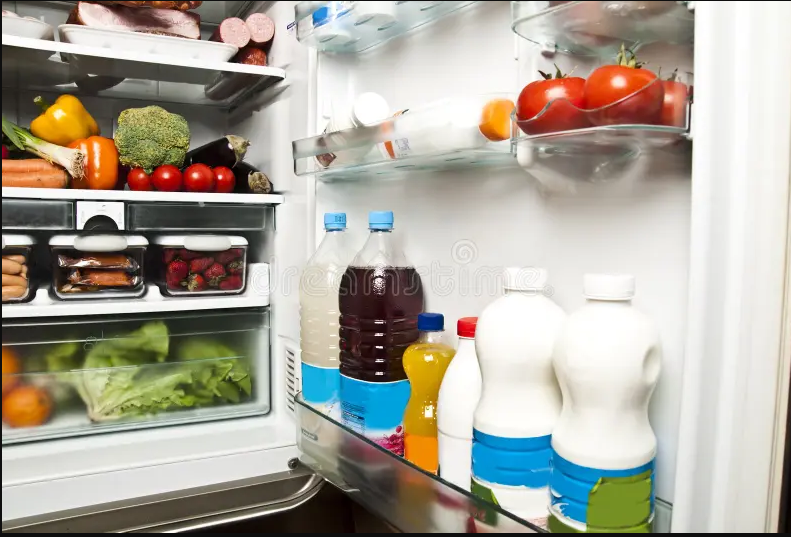

Ingredientes detectados: ['egg', 'sausage', 'ham', 'yellow bell pepper', 'carrot', 'leek', 'broccoli', 'cherry tomato', 'eggplant', 'orange', 'strawberry', 'lettuce', 'milk', 'orange juice', 'water']


In [5]:

NOMBRE_FOTO = "foto_refri.jpg"
ruta_foto = CARPETA_NOTEBOOK / NOMBRE_FOTO

if not ruta_foto.exists():
    raise FileNotFoundError(
        f"No encontré '{NOMBRE_FOTO}' en {CARPETA_NOTEBOOK}. "
        "Coloca una foto de tu refri/despensa con ese nombre en esta carpeta y vuelve a correr esta celda."
    )

display(IPImage(filename=str(ruta_foto), width=400))

ingredientes_detectados = identificar_ingredientes_de_foto(ruta_foto.read_bytes())
print("Ingredientes detectados:", ingredientes_detectados)



## Paso 2 — Ingredientes → opciones de receta reales (con imagen y nutrición)


In [6]:

opciones = buscar_opciones_comida(ingredientes_detectados, n_opciones=3)

for o in opciones:
    print(f"\n=== {o['titulo']} ===")
    if o.get("imagen_url"):
        display(IPImage(url=o["imagen_url"], width=250))
    print(f"{o['calorias']} kcal · {o['proteina_g']}g proteína · {o['grasa_g']}g grasa · {o['carbohidratos_g']}g carbs")
    print(f"Usa: {o['ingredientes_usados']}")
    print(f"Te faltaría: {o['ingredientes_faltantes']}")



=== Chinese Steamed Flan ===


251.5 kcal · 7.8g proteína · 6.3g grasa · 42.9g carbs
Usa: ['eggs', 'strawberries', 'milk']
Te faltaría: ['vanilla']

=== Vintage Project: Strawberry Sponge Pie ===


191.1 kcal · 3.4g proteína · 6.0g grasa · 32.2g carbs
Usa: ['eggs', 'milk', 'strawberries']
Te faltaría: ['unbaked pie shell']

=== Square Deviled Eggs ===


211.6 kcal · 18.5g proteína · 14.7g grasa · 0.1g carbs
Usa: ['eggs', 'ham']
Te faltaría: ['cream cheese']


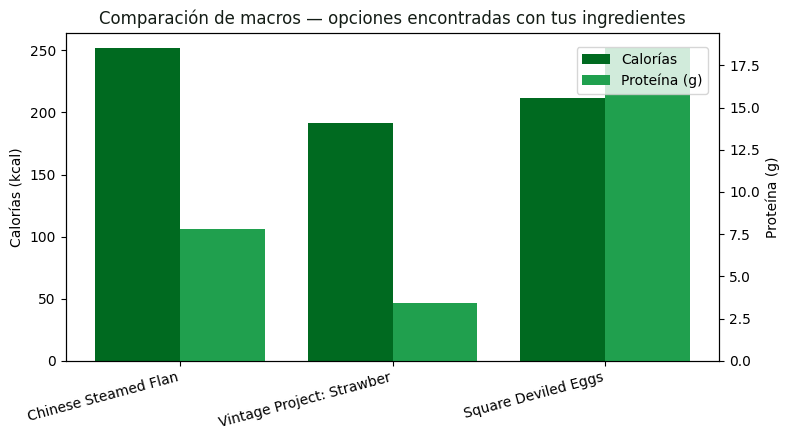

In [7]:

# Comparación visual de macros entre las opciones encontradas
if opciones:
    titulos = [o["titulo"][:25] for o in opciones]
    calorias = [o["calorias"] or 0 for o in opciones]
    proteina = [o["proteina_g"] or 0 for o in opciones]

    fig, ax1 = plt.subplots(figsize=(8, 4.5))
    x = range(len(titulos))
    ax1.bar([i - 0.2 for i in x], calorias, width=0.4, color=VERDE_PRIMARIO, label="Calorías")
    ax1.set_ylabel("Calorías (kcal)")
    ax2 = ax1.twinx()
    ax2.bar([i + 0.2 for i in x], proteina, width=0.4, color=VERDE_MEDIO, label="Proteína (g)")
    ax2.set_ylabel("Proteína (g)")
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(titulos, rotation=15, ha="right")
    ax1.set_title("Comparación de macros — opciones encontradas con tus ingredientes", color=CASI_NEGRO)
    fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
    plt.tight_layout()
    plt.show()



## Paso 3 — Meta nutricional del usuario (Mifflin-St Jeor, sin API)
Perfil de ejemplo genérico

In [8]:

perfil_ejemplo = {"weight_kg": 75, "height_cm": 178, "age": 28, "gender_code": "M", "objetivo": "Ganar músculo"}
metas = calcular_objetivo_nutricional(perfil_ejemplo)
metas


{'calorias': 2805, 'proteina_g': 150, 'grasa_g': 84, 'carbohidratos_g': 362}


## Paso 4 — Recomendadas para tu objetivo (independiente del refri)


In [9]:

opciones_objetivo = buscar_comidas_por_objetivo(metas, n_opciones=3)

for o in opciones_objetivo:
    print(f"\n=== {o['titulo']} ===")
    if o.get("imagen_url"):
        display(IPImage(url=o["imagen_url"], width=250))
    print(f"{o['calorias']} kcal · {o['proteina_g']}g proteína · {o['grasa_g']}g grasa · {o['carbohidratos_g']}g carbs")



=== Roasted Lemon Pepper Pork Tenderloin with Cornbread Stuffing ===


705.4 kcal · 47.5g proteína · 25.1g grasa · 71.7g carbs

=== Mexican Chicken & Rice Bowl ===


838.7 kcal · 61.9g proteína · 37.0g grasa · 68.3g carbs

=== Chicken Adobo & Coconut Ginger Rice ===


729.8 kcal · 32.6g proteína · 34.5g grasa · 69.5g carbs



## Paso 5 — Instrucciones de preparación reales


In [10]:

if opciones:
    receta_elegida = opciones[0]
    instrucciones = obtener_instrucciones_preparacion(receta_elegida["id"], receta_elegida["titulo"])
    if instrucciones["es_generada_por_ia"]:
        print("⚠️ No había instrucciones oficiales — esta es una sugerencia general del LLM.")
    print(instrucciones["texto"])


1. **Prepara el caramelo:**  
   Extiende el azúcar de manera uniforme en el fondo de una cacerola pesada y ponla a fuego medio-bajo. Puede tardar varios minutos en empezar a derretirse. Sin remover, vigila el azúcar de cerca mientras comienza a licuarse por los bordes. Poco a poco pasará de amarillo a dorado y finalmente a un caramelo marrón.

2. **Vierte el caramelo en los moldes:**  
   Cuando el azúcar licuada empiece a pasar de dorado a marrón, retira inmediatamente la cacerola del fuego. ¡Ten mucho cuidado! Si te pasas, el azúcar se oscurecerá demasiado y tendrás que empezar de nuevo. Vierte enseguida el caramelo líquido en 6 ramequines de 3 1/2 pulgadas y gíralos para cubrir bien el fondo. El caramelo se endurece rápidamente, así que trabaja con rapidez. Reserva.

3. **Prepara el flan:**  
   Coloca unos 5 cm de agua en la parte inferior de una vaporera. Tápala y deja que el agua hierva. Mientras tanto, calienta la leche y el azúcar en una cacerola solo hasta que estén tibios y 


## Nota sobre XP (sin API, es lógica de negocio)

## El pipeline propuesto por reglas de negocio, de punta a punta

```
Foto o texto del usuario
        │
        ▼
[Visión LLM]  identificar_ingredientes_de_foto
        │
        ▼
[Traducción LLM]  traducir_ingredientes_a_ingles   (ES/EN mixto -> EN)
        │
        ▼
[Spoonacular]  findByIngredients (ranking=2)  ->  informationBulk
        │
        ▼
Usuario ve tarjetas -> elige una -> confirma
        │
        ▼
[Spoonacular + LLM]  obtener_instrucciones_preparacion
        │
        ▼
[utils_db]  registrar_interaccion_nutricion(..., xp_ganado=60)
```

En paralelo:

```
Perfil del usuario -> [Mifflin-St Jeor] -> metas diarias -> [Spoonacular] buscar_comidas_por_objetivo
```
